In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

TRAIN_PATH = "/kaggle/input/mai-ml-lab-1-fiit-2025/train.csv"
TEST_PATH  = "/kaggle/input/mai-ml-lab-1-fiit-2025/test.csv"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print("Train:", train.shape)
print("Test:", test.shape)

Train: (11017, 35)
Test: (5000, 35)


In [46]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def manual_standardize(X):
    X = np.asarray(X, dtype=float)
    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=0)  # как в sklearn
    std_corrected = np.where(std == 0, 1.0, std)
    X_scaled = (X - mean) / std_corrected
    return X_scaled, mean, std_corrected


def manual_minmax_scale(X):
    X = np.asarray(X, dtype=float)
    min_val = X.min(axis=0)
    max_val = X.max(axis=0)
    range_val = max_val - min_val
    range_corrected = np.where(range_val == 0, 1.0, range_val)
    X_scaled = (X - min_val) / range_corrected
    return X_scaled, min_val, max_val

X_test = np.array([
    [1, 2],
    [3, 4],
    [5, 6],
    [7, 8]
], dtype=float)

manual_z, m_mean, m_std = manual_standardize(X_test)
manual_mm, m_min, m_max = manual_minmax_scale(X_test)

sk_z = StandardScaler().fit_transform(X_test)
sk_mm = MinMaxScaler().fit_transform(X_test)

print("Z-score совпадает:",
      np.allclose(manual_z, sk_z, atol=1e-10))

print("Max разница (z-score):",
      np.abs(manual_z - sk_z).max())

print("\nMin-Max совпадает:",
      np.allclose(manual_mm, sk_mm, atol=1e-10))

print("Max разница (min-max):",
      np.abs(manual_mm - sk_mm).max())

Z-score совпадает: True
Max разница (z-score): 0.0

Min-Max совпадает: True
Max разница (min-max): 1.1102230246251565e-16


In [7]:
import numpy as np

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    root_mean_squared_error = None


def mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 0.0 if ss_tot == 0 else 1.0 - ss_res / ss_tot


def mape(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


def smape(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

y_true_test = np.array([10, 20, 30, 40, 50], dtype=float)
y_pred_test = np.array([12, 18, 29, 41, 55], dtype=float)

if root_mean_squared_error is not None:
    sk_rmse = root_mean_squared_error(y_true_test, y_pred_test)
else:
    sk_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))

print("Сравнение метрик на тестовых данных:\n")

print(f"MSE  manual:  {mse(y_true_test, y_pred_test):.10f}")
print(f"MSE  sklearn: {mean_squared_error(y_true_test, y_pred_test):.10f}")

print(f"\nRMSE manual:  {rmse(y_true_test, y_pred_test):.10f}")
print(f"RMSE sklearn: {sk_rmse:.10f}")

print(f"\nMAE  manual:  {mae(y_true_test, y_pred_test):.10f}")
print(f"MAE  sklearn: {mean_absolute_error(y_true_test, y_pred_test):.10f}")

print(f"\nR2   manual:  {r2(y_true_test, y_pred_test):.10f}")
print(f"R2   sklearn: {r2_score(y_true_test, y_pred_test):.10f}")

print(f"\nMAPE manual:  {mape(y_true_test, y_pred_test):.10f}%")
print(f"sMAPE manual: {smape(y_true_test, y_pred_test):.10f}%")

Сравнение метрик на тестовых данных:

MSE  manual:  7.0000000000
MSE  sklearn: 7.0000000000

RMSE manual:  2.6457513111
RMSE sklearn: 2.6457513111

MAE  manual:  2.2000000000
MAE  sklearn: 2.2000000000

R2   manual:  0.9650000000
R2   sklearn: 0.9650000000

MAPE manual:  9.1666666667%
sMAPE manual: 8.8181819612%


In [9]:
import numpy as np
from sklearn.linear_model import LinearRegression as SkLinearRegression

def my_mse(y_true, y_pred): return np.mean((y_true - y_pred) ** 2)
def my_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 0.0 if ss_tot == 0 else 1 - ss_res / ss_tot


class MyLinearRegression:

    def __init__(
        self,
        method="normal",
        learning_rate=0.01,
        n_iterations=1000,
        batch_size=32,
        fit_intercept=True,
        random_state=42,
        tol=0.0,
    ):
        self.method = method
        self.learning_rate = float(learning_rate)
        self.n_iterations = int(n_iterations)
        self.batch_size = int(batch_size)
        self.fit_intercept = bool(fit_intercept)
        self.random_state = int(random_state)
        self.tol = float(tol)

        self.weights = None
        self.bias = 0.0

    def _add_bias_column(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X]

    def _init_params(self, n_features):
        self.weights = np.zeros(n_features, dtype=float)
        self.bias = 0.0

    def _predict_raw(self, X):
        # predict без приведения типов, чтобы в циклах было быстрее
        if self.fit_intercept:
            return X @ self.weights + self.bias
        return X @ self.weights

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self._predict_raw(X)

    def _fit_normal(self, X, y):
        if self.fit_intercept:
            Xb = self._add_bias_column(X)
            theta, *_ = np.linalg.lstsq(Xb, y, rcond=None)
            self.bias = float(theta[0])
            self.weights = theta[1:].astype(float)
        else:
            theta, *_ = np.linalg.lstsq(X, y, rcond=None)
            self.bias = 0.0
            self.weights = theta.astype(float)

    def _grad(self, X, y):
        n = X.shape[0]
        y_pred = self._predict_raw(X)
        err = y_pred - y  # (pred - true)
        dw = (2.0 / n) * (X.T @ err)
        db = (2.0 / n) * np.sum(err) if self.fit_intercept else 0.0
        return dw, db

    def _fit_gd(self, X, y):
        n_samples, n_features = X.shape
        self._init_params(n_features)

        prev_loss = None
        for _ in range(self.n_iterations):
            dw, db = self._grad(X, y)
            self.weights -= self.learning_rate * dw
            if self.fit_intercept:
                self.bias -= self.learning_rate * db

            if self.tol > 0:
                loss = my_mse(y, self._predict_raw(X))
                if prev_loss is not None and abs(prev_loss - loss) < self.tol:
                    break
                prev_loss = loss

    def _fit_sgd(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n_samples, n_features = X.shape
        self._init_params(n_features)

        for _ in range(self.n_iterations):
            idx = rng.permutation(n_samples)
            Xs, ys = X[idx], y[idx]

            for start in range(0, n_samples, self.batch_size):
                Xb = Xs[start:start + self.batch_size]
                yb = ys[start:start + self.batch_size]
                dw, db = self._grad(Xb, yb)
                self.weights -= self.learning_rate * dw
                if self.fit_intercept:
                    self.bias -= self.learning_rate * db

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        if self.method == "normal":
            self._fit_normal(X, y)
        elif self.method == "gd":
            self._fit_gd(X, y)
        elif self.method == "sgd":
            self._fit_sgd(X, y)
        else:
            raise ValueError("method must be one of {'normal', 'gd', 'sgd'}")

        return self

np.random.seed(42)
X_simple = np.random.randn(120, 3)
noise = np.random.randn(120) * 0.5
y_simple = 3 * X_simple[:, 0] + 2 * X_simple[:, 1] - 1 * X_simple[:, 2] + 5 + noise

print("Сравнение методов:\n")

models = {
    "Аналитическое (lstsq)": MyLinearRegression(method="normal"),
    "GD": MyLinearRegression(method="gd", learning_rate=0.1, n_iterations=2000, tol=0.0),
    "Mini-batch SGD": MyLinearRegression(method="sgd", learning_rate=0.1, n_iterations=200, batch_size=16, random_state=42),
}

for title, mdl in models.items():
    mdl.fit(X_simple, y_simple)
    preds = mdl.predict(X_simple)
    print(f"{title}:")
    print(f"  MSE: {my_mse(y_simple, preds):.6f}")
    print(f"  R2:  {my_r2(y_simple, preds):.6f}")
    print(f"  Weights: {np.round(mdl.weights, 6)}")
    print(f"  Bias:    {mdl.bias:.6f}\n")

sk_model = SkLinearRegression().fit(X_simple, y_simple)
sk_preds = sk_model.predict(X_simple)
print("Sklearn LinearRegression:")
print(f"  MSE: {my_mse(y_simple, sk_preds):.6f}")
print(f"  R2:  {my_r2(y_simple, sk_preds):.6f}")
print(f"  Weights: {np.round(sk_model.coef_, 6)}")
print(f"  Bias:    {sk_model.intercept_:.6f}")

Сравнение методов:

Аналитическое (lstsq):
  MSE: 0.268243
  R2:  0.976288
  Weights: [ 2.942459  1.912257 -1.082091]
  Bias:    5.027965

GD:
  MSE: 0.268243
  R2:  0.976288
  Weights: [ 2.942459  1.912257 -1.082091]
  Bias:    5.027965

Mini-batch SGD:
  MSE: 0.271386
  R2:  0.976011
  Weights: [ 2.919432  1.871046 -1.081705]
  Bias:    4.985687

Sklearn LinearRegression:
  MSE: 0.268243
  R2:  0.976288
  Weights: [ 2.942459  1.912257 -1.082091]
  Bias:    5.027965


In [11]:
import numpy as np
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score
from sklearn.linear_model import LinearRegression


def my_kfold_cv(X, y, model_class, model_params=None,
                k=5, metric_fn=my_mse, shuffle=True, random_state=42):

    if model_params is None:
        model_params = {}

    X = np.asarray(X)
    y = np.asarray(y)

    n = len(X)
    idx = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(idx)

    folds = np.array_split(idx, k)
    scores = []

    for val_idx in folds:
        train_idx = np.setdiff1d(idx, val_idx)

        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        model = model_class(**model_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        scores.append(metric_fn(y_val, preds))

    return np.asarray(scores)


def my_loocv(X, y, model_class, model_params=None, metric_fn=my_mse):
    if model_params is None:
        model_params = {}

    X = np.asarray(X)
    y = np.asarray(y)

    n = len(X)
    scores = []

    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False

        model = model_class(**model_params)
        model.fit(X[mask], y[mask])

        pred = model.predict(X[i:i+1])
        scores.append(metric_fn(y[i:i+1], pred))

    return np.asarray(scores)


X_cv_test = X_simple[:50]
y_cv_test = y_simple[:50]

print("Тестирование кросс-валидации:\n")

my_kfold_scores = my_kfold_cv(
    X_cv_test,
    y_cv_test,
    model_class=MyLinearRegression,
    model_params={"method": "normal"},
    k=5,
    random_state=42
)

print("Моя K-Fold (k=5):")
print(f"  Scores: {np.round(my_kfold_scores, 6)}")
print(f"  Mean MSE: {my_kfold_scores.mean():.6f} (+/- {my_kfold_scores.std():.6f})")


sklearn_kf = KFold(n_splits=5, shuffle=True, random_state=42)
sklearn_scores = -cross_val_score(
    LinearRegression(),
    X_cv_test,
    y_cv_test,
    cv=sklearn_kf,
    scoring="neg_mean_squared_error"
)

print("\nSklearn K-Fold (k=5):")
print(f"  Mean MSE: {sklearn_scores.mean():.6f} (+/- {sklearn_scores.std():.6f})")


X_loo_test = X_simple[:20]
y_loo_test = y_simple[:20]

my_loo_scores = my_loocv(
    X_loo_test,
    y_loo_test,
    model_class=MyLinearRegression,
    model_params={"method": "normal"}
)

print("\nМоя Leave-One-Out (n=20):")
print(f"  Mean MSE: {my_loo_scores.mean():.6f} (+/- {my_loo_scores.std():.6f})")


sklearn_loo = LeaveOneOut()
sklearn_loo_scores = -cross_val_score(
    LinearRegression(),
    X_loo_test,
    y_loo_test,
    cv=sklearn_loo,
    scoring="neg_mean_squared_error"
)

print("\nSklearn Leave-One-Out (n=20):")
print(f"  Mean MSE: {sklearn_loo_scores.mean():.6f} (+/- {sklearn_loo_scores.std():.6f})")

Тестирование кросс-валидации:

Моя K-Fold (k=5):
  Scores: [0.339194 0.293151 0.159466 0.217189 0.399913]
  Mean MSE: 0.281783 (+/- 0.085456)

Sklearn K-Fold (k=5):
  Mean MSE: 0.248284 (+/- 0.080982)

Моя Leave-One-Out (n=20):
  Mean MSE: 0.196862 (+/- 0.221332)

Sklearn Leave-One-Out (n=20):
  Mean MSE: 0.196862 (+/- 0.221332)


In [12]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet

class MyRegularizedLinearRegression:

    def __init__(
        self,
        reg_type="l2",
        alpha=1.0,
        l1_ratio=0.5,
        p=2.0,
        learning_rate=0.01,
        n_iterations=2000,
        random_state=42,
        tol=0.0,
    ):
        self.reg_type = reg_type
        self.alpha = float(alpha)
        self.l1_ratio = float(l1_ratio)
        self.p = float(p)
        self.learning_rate = float(learning_rate)
        self.n_iterations = int(n_iterations)
        self.random_state = int(random_state)
        self.tol = float(tol)

        self.weights = None
        self.bias = 0.0

    def _reg_grad(self):
        w = self.weights
        if self.reg_type == "l2":
            return 2.0 * self.alpha * w
        if self.reg_type == "l1":
            return self.alpha * np.sign(w)
        if self.reg_type == "elastic":
            l1 = self.alpha * self.l1_ratio * np.sign(w)
            l2 = self.alpha * (1.0 - self.l1_ratio) * 2.0 * w
            return l1 + l2
        if self.reg_type == "lp":
            w_abs = np.abs(w) + 1e-8
            return self.alpha * self.p * (w_abs ** (self.p - 1.0)) * np.sign(w)
        raise ValueError("reg_type must be one of {'l2','l1','elastic','lp'}")

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n, d = X.shape

        self.weights = np.zeros(d, dtype=float)
        self.bias = 0.0

        prev_loss = None
        for _ in range(self.n_iterations):
            y_pred = X @ self.weights + self.bias
            err = y_pred - y

            dw = (2.0 / n) * (X.T @ err)
            db = (2.0 / n) * np.sum(err)

            dw = dw + self._reg_grad()

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            if self.tol > 0:
                loss = np.mean(err ** 2)
                if prev_loss is not None and abs(prev_loss - loss) < self.tol:
                    break
                prev_loss = loss

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.weights + self.bias

np.random.seed(42)
X_reg = np.random.randn(120, 5)
X_reg[:, 3] = X_reg[:, 0] + np.random.randn(120) * 0.1
X_reg[:, 4] = X_reg[:, 1] + np.random.randn(120) * 0.1
y_reg = 3 * X_reg[:, 0] + 2 * X_reg[:, 1] + np.random.randn(120) * 0.5

base = MyLinearRegression(method="normal").fit(X_reg, y_reg)
base_pred = base.predict(X_reg)
print("Без регуляризации:")
print(f"  MSE: {my_mse(y_reg, base_pred):.6f}")
print(f"  L2-norm весов: {np.linalg.norm(base.weights):.6f}")

configs = [
    ("L2 (alpha=1.0)", {"reg_type": "l2", "alpha": 1.0}),
    ("L1 (alpha=0.1)", {"reg_type": "l1", "alpha": 0.1}),
    ("Elastic (alpha=0.5, l1_ratio=0.5)", {"reg_type": "elastic", "alpha": 0.5, "l1_ratio": 0.5}),
    ("Lp (p=1.5, alpha=0.5)", {"reg_type": "lp", "alpha": 0.5, "p": 1.5}),
]

for title, params in configs:
    mdl = MyRegularizedLinearRegression(learning_rate=0.05, n_iterations=3000, tol=0.0, **params)
    mdl.fit(X_reg, y_reg)
    pred = mdl.predict(X_reg)

    print(f"\n{title}:")
    print(f"  MSE: {my_mse(y_reg, pred):.6f}")
    if params["reg_type"] == "l1":
        nnz = np.sum(np.abs(mdl.weights) > 1e-2)
        print(f"  ~Ненулевых весов: {nnz}/{len(mdl.weights)}")
        print(f"  Weights: {np.round(mdl.weights, 6)}")
    elif params["reg_type"] == "lp":
        lp_norm = np.sum(np.abs(mdl.weights) ** params["p"])
        print(f"  Lp-norm (p={params['p']}): {lp_norm:.6f}")
    else:
        print(f"  L2-norm весов: {np.linalg.norm(mdl.weights):.6f}")

ridge = Ridge(alpha=1.0).fit(X_reg, y_reg)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_reg, y_reg)
enet  = ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=10000).fit(X_reg, y_reg)

print("\nSklearn (для проверки):")
print(f"  Ridge MSE: {my_mse(y_reg, ridge.predict(X_reg)):.6f}, L2-norm: {np.linalg.norm(ridge.coef_):.6f}")
print(f"  Lasso MSE: {my_mse(y_reg, lasso.predict(X_reg)):.6f}, nnz: {np.sum(np.abs(lasso.coef_)>1e-6)}/{len(lasso.coef_)}")
print(f"  ElasticNet MSE: {my_mse(y_reg, enet.predict(X_reg)):.6f}, nnz: {np.sum(np.abs(enet.coef_)>1e-6)}/{len(enet.coef_)}")

Сравнение регуляризаций (учебный эксперимент, НЕ для соревнования):

Без регуляризации:
  MSE: 0.203618
  L2-norm весов: 3.441613

L2 (alpha=1.0):
  MSE: 1.749025
  L2-norm весов: 1.510324

L1 (alpha=0.1):
  MSE: 0.214445
  ~Ненулевых весов: 5/5
  Weights: [ 2.655893  1.740877 -0.045742  0.208208  0.168867]

Elastic (alpha=0.5, l1_ratio=0.5):
  MSE: 0.613799
  L2-norm весов: 2.013865

Lp (p=1.5, alpha=0.5):
  MSE: 0.605902
  Lp-norm (p=1.5): 4.001364

Sklearn (для проверки):
  Ridge MSE: 0.214745, L2-norm: 2.663074
  Lasso MSE: 0.239097, nnz: 2/5
  ElasticNet MSE: 0.851990, nnz: 4/5


In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

def my_mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)

def my_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

def my_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 0.0 if ss_tot == 0 else 1 - ss_res / ss_tot

def my_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def z_score_manual(arr):
    arr = np.asarray(arr, dtype=float)
    mu = arr.mean(axis=0)
    sigma = arr.std(axis=0)
    sigma = np.where(sigma == 0, 1.0, sigma)
    return (arr - mu) / sigma, mu, sigma

def min_max_manual(arr):
    arr = np.asarray(arr, dtype=float)
    lo = arr.min(axis=0)
    hi = arr.max(axis=0)
    span = np.where((hi - lo) == 0, 1.0, hi - lo)
    return (arr - lo) / span, lo, hi

class MyLinearRegression:
    def __init__(self, method="normal", learning_rate=0.01, n_iterations=1000):
        self.method = method
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = 0.0

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n, d = X.shape
        if self.method == "normal":
            Xb = np.c_[np.ones((n, 1)), X]
            theta, *_ = np.linalg.lstsq(Xb, y, rcond=None)
            self.bias = theta[0]
            self.weights = theta[1:]
        else:
            self.weights = np.zeros(d)
            self.bias = 0.0
            for _ in range(self.n_iterations):
                preds = self.predict(X)
                err = preds - y
                dw = (2 / n) * (X.T @ err)
                db = (2 / n) * err.sum()
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db
        return self

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.weights + self.bias

class MyRegularizedLinearRegression:
    def __init__(self, reg_type="l2", alpha=1.0, l1_ratio=0.5, p=2.0, learning_rate=0.01, n_iterations=1000):
        self.reg_type = reg_type
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.p = p
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = 0.0

    def _reg_grad(self):
        if self.reg_type == "l2":
            return 2 * self.alpha * self.weights
        if self.reg_type == "l1":
            return self.alpha * np.sign(self.weights)
        if self.reg_type == "elastic":
            l1 = self.alpha * self.l1_ratio * np.sign(self.weights)
            l2 = self.alpha * (1 - self.l1_ratio) * 2 * self.weights
            return l1 + l2
        if self.reg_type == "lp":
            w_abs = np.abs(self.weights) + 1e-8
            return self.alpha * self.p * (w_abs ** (self.p - 1)) * np.sign(self.weights)
        raise ValueError("Unsupported reg_type")

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n, d = X.shape
        self.weights = np.zeros(d)
        self.bias = 0.0
        for _ in range(self.n_iterations):
            preds = self.predict(X)
            err = preds - y
            dw = (2 / n) * (X.T @ err) + self._reg_grad()
            db = (2 / n) * err.sum()
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
        return self

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.weights + self.bias

def my_kfold_cv(X, y, model, k=5):
    X = np.asarray(X)
    y = np.asarray(y)
    idx = np.random.permutation(len(X))
    folds = np.array_split(idx, k)
    scores = []
    for val_idx in folds:
        train_idx = np.setdiff1d(idx, val_idx)
        mdl = MyLinearRegression(method=model.method)
        mdl.fit(X[train_idx], y[train_idx])
        preds = mdl.predict(X[val_idx])
        scores.append(my_mse(y[val_idx], preds))
    return np.asarray(scores)

def my_loocv(X, y, model):
    X = np.asarray(X)
    y = np.asarray(y)
    scores = []
    for i in range(len(X)):
        mask = np.ones(len(X), dtype=bool)
        mask[i] = False
        mdl = MyLinearRegression(method=model.method)
        mdl.fit(X[mask], y[mask])
        pred = mdl.predict(X[i:i+1])
        scores.append(my_mse(y[i:i+1], pred))
    return np.asarray(scores)

np.random.seed(123)

X_demo = np.random.randn(200, 4)
y_demo = 2*X_demo[:,0] + 3*X_demo[:,1] - X_demo[:,2] + 0.5*X_demo[:,3] + 10 + np.random.randn(200)*0.8

X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_demo, y_demo, test_size=0.3, random_state=42
)

print(f"\nУчебный датасет: {X_train_demo.shape[0]} train, {X_test_demo.shape[0]} test samples")
print("\n1. НОРМАЛИЗАЦИЯ")
X_zscore, _, _ = z_score_manual(X_train_demo)
X_minmax, _, _ = min_max_manual(X_train_demo)
print("Z-score и Min-max реализованы")

print("\n2. МЕТРИКИ")
base_model = MyLinearRegression(method="normal").fit(X_train_demo, y_train_demo)
y_pred_metrics = base_model.predict(X_test_demo)
print(f"MSE:  {my_mse(y_test_demo, y_pred_metrics):.4f}")
print(f"MAE:  {my_mae(y_test_demo, y_pred_metrics):.4f}")
print(f"R2:   {my_r2(y_test_demo, y_pred_metrics):.4f}")
print(f"MAPE: {my_mape(y_test_demo, y_pred_metrics):.4f}%")

print("\n3. ЛИНЕЙНАЯ РЕГРЕССИЯ")
for method in ("normal", "gd"):
    lr = MyLinearRegression(method=method, learning_rate=0.1, n_iterations=1000)
    lr.fit(X_train_demo, y_train_demo)
    print(f"{method:10s} MSE: {my_mse(y_test_demo, lr.predict(X_test_demo)):.4f}")

sk_lr = LinearRegression().fit(X_train_demo, y_train_demo)
print(f"sklearn     MSE: {my_mse(y_test_demo, sk_lr.predict(X_test_demo)):.4f}")

print("\n4. КРОСС-ВАЛИДАЦИЯ")
model_cv = MyLinearRegression(method="normal")
kfold_scores = my_kfold_cv(X_train_demo, y_train_demo, model_cv, k=5)
print(f"K-Fold MSE: {kfold_scores.mean():.4f} (+/- {kfold_scores.std():.4f})")

loo_scores = my_loocv(X_train_demo[:30], y_train_demo[:30], model_cv)
print(f"LOO MSE:    {loo_scores.mean():.4f} (+/- {loo_scores.std():.4f})")

print("\n5. РЕГУЛЯРИЗАЦИЯ")
reg = MyRegularizedLinearRegression(reg_type="l2", alpha=1.0, learning_rate=0.1)
reg.fit(X_train_demo, y_train_demo)
print(f"L2 MSE: {my_mse(y_test_demo, reg.predict(X_test_demo)):.4f}")


Учебный датасет: 140 train, 60 test samples

1. НОРМАЛИЗАЦИЯ
Z-score и Min-max реализованы

2. МЕТРИКИ
MSE:  0.6003
MAE:  0.6034
R2:   0.9498
MAPE: 5.9763%

3. ЛИНЕЙНАЯ РЕГРЕССИЯ
normal     MSE: 0.6003
gd         MSE: 0.6003
sklearn     MSE: 0.6003

4. КРОСС-ВАЛИДАЦИЯ
K-Fold MSE: 0.6210 (+/- 0.1030)
LOO MSE:    0.5188 (+/- 0.5082)

5. РЕГУЛЯРИЗАЦИЯ
L2 MSE: 4.0742


Пропущенные значения:


,missing_count,missing_percent
MonthlyDebtPayments,1031,9.358265
LoanAmount,1031,9.358265
CreditScore,1031,9.358265
BaseInterestRate,1031,9.358265
NetWorth,1031,9.358265
TotalAssets,1031,9.358265
BankruptcyHistory,1031,9.358265
LoanPurpose,1031,9.358265
CheckingAccountBalance,1031,9.358265
ApplicationDate,530,4.810747


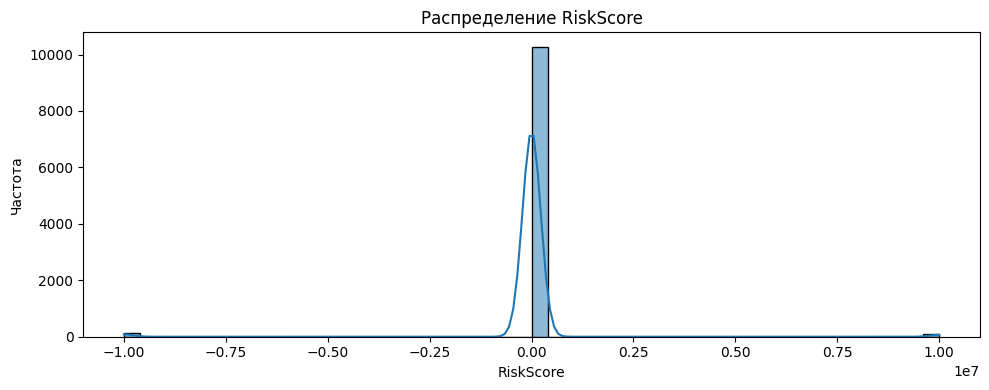


Статистика RiskScore:
count    1.048700e+04
mean    -2.569878e+04
std      1.431675e+06
min     -9.999999e+06
25%      3.256475e+01
50%      4.411876e+01
75%      6.535690e+01
max      1.000000e+07
Name: RiskScore, dtype: float64

Skewness RiskScore: -0.8237


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

missing = train.isna().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(train) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing.sort_values(ascending=False),
    "missing_percent": missing_pct
})

print("Пропущенные значения:")
display(missing_df)

plt.figure(figsize=(10, 4))
sns.histplot(train["RiskScore"].dropna(), bins=50, kde=True)
plt.title("Распределение RiskScore")
plt.xlabel("RiskScore")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

print("\nСтатистика RiskScore:")
print(train["RiskScore"].describe())

print(f"\nSkewness RiskScore: {train['RiskScore'].skew():.4f}")

In [18]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_with_target = train[numeric_cols].corr()["RiskScore"].abs().sort_values(ascending=False)
print("\n15 признаков по корреляции с RiskScore:")
print(corr_with_target.head(15))


15 признаков по корреляции с RiskScore:
RiskScore                     1.000000
NumberOfDependents            0.023314
PaymentHistory                0.019144
TotalDebtToIncomeRatio        0.013879
UtilityBillsPaymentHistory    0.013865
MonthlyLoanPayment            0.012366
LoanAmount                    0.011771
NumberOfCreditInquiries       0.011055
LengthOfCreditHistory         0.009448
NetWorth                      0.008804
AnnualIncome                  0.008460
TotalAssets                   0.008092
SavingsAccountBalance         0.007611
DebtToIncomeRatio             0.007417
MonthlyIncome                 0.006145
Name: RiskScore, dtype: float64


In [19]:
import numpy as np
import pandas as pd

numeric_cols = train.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "RiskScore"]

corr_matrix = train[numeric_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []
cols_to_drop = set()

for col in upper.columns:
    for row in upper.index:
        corr_val = upper.loc[row, col]
        if pd.notna(corr_val) and corr_val > 0.95:
            high_corr_pairs.append((row, col, corr_val))
            cols_to_drop.add(col)

print("\nСильно коррелирующие пары (|r| > 0.95):")
for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    print(f"  {f1} <-> {f2}: r = {val:.4f}")

print(f"\nНайдено пар: {len(high_corr_pairs)}")

if cols_to_drop:
    print(f"\nБудут удалены признаки: {sorted(cols_to_drop)}")
else:
    print("\nСильно коррелирующих признаков не найдено")


Сильно коррелирующие пары (|r| > 0.95):
  TotalAssets <-> NetWorth: r = 0.9940
  AnnualIncome <-> MonthlyIncome: r = 0.9854
  Age <-> Experience: r = 0.9830
  BaseInterestRate <-> InterestRate: r = 0.9754

Найдено пар: 4

Будут удалены признаки: ['Experience', 'InterestRate', 'MonthlyIncome', 'NetWorth']


In [20]:
df = train.copy()
test_df = test.copy()

print("Исходные размеры:")
print(f"Train: {df.shape}, Test: {test_df.shape}")

core_drop = {
    "AnnualIncome",
    "NetWorth",
    "Experience",
    "InterestRate",
    "ApplicationDate",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose",
}

cols_to_drop_train = [c for c in core_drop if c in df.columns and c != "RiskScore"]
cols_to_drop_test  = [c for c in core_drop if c in test_df.columns and c != "ID"]

df.drop(columns=cols_to_drop_train, inplace=True)
test_df.drop(columns=cols_to_drop_test, inplace=True)

print("\nУдалённые признаки:")
print("Train:", cols_to_drop_train)
print("Test :", cols_to_drop_test)

print("\nПосле удаления признаков:")
print(f"Train: {df.shape}, Test: {test_df.shape}")

Исходные размеры:
Train: (11017, 35), Test: (5000, 35)

Удалённые признаки:
Train: ['LoanPurpose', 'ApplicationDate', 'MaritalStatus', 'NetWorth', 'AnnualIncome', 'HomeOwnershipStatus', 'InterestRate', 'Experience']
Test : ['LoanPurpose', 'ApplicationDate', 'MaritalStatus', 'NetWorth', 'AnnualIncome', 'HomeOwnershipStatus', 'InterestRate', 'Experience']

После удаления признаков:
Train: (11017, 27), Test: (5000, 27)


In [21]:
import numpy as np

def create_features(data):
    d = data.copy()
    eps = 1e-9

    def safe_div(a, b):
        return a / (b + eps)

    if "BankruptcyHistory" in d.columns:
        d["HasBankruptcy"] = (d["BankruptcyHistory"].fillna(0) > 0).astype(int)
        d["BankruptcyHistory_log"] = np.log1p(d["BankruptcyHistory"].fillna(0).clip(lower=0))

    if "PreviousLoanDefaults" in d.columns:
        d["HasDefaults"] = (d["PreviousLoanDefaults"].fillna(0) > 0).astype(int)
        d["PreviousLoanDefaults_log"] = np.log1p(d["PreviousLoanDefaults"].fillna(0).clip(lower=0))

    for col, new_col in [
        ("MonthlyIncome", "Income_log"),
        ("LoanAmount", "LoanAmount_log"),
        ("MonthlyDebtPayments", "DebtPayments_log"),
    ]:
        if col in d.columns:
            d[new_col] = np.log1p(d[col].fillna(0).clip(lower=0))

    for col in ["CreditScore", "Age"]:
        if col in d.columns:
            base = d[col].fillna(d[col].median())
            d[f"{col}_sq"] = base ** 2
            d[f"{col}_cubed"] = base ** 3

    for col, new_col in [
        ("TotalDebtToIncomeRatio", "TotalDebtToIncomeRatio_sqrt"),
        ("LoanAmount", "LoanAmount_sqrt"),
        ("Age", "Age_sqrt"),
    ]:
        if col in d.columns:
            d[new_col] = np.sqrt(d[col].fillna(0).clip(lower=0))

    for c1, c2, name, fn in [
        ("TotalAssets", "NumberOfDependents", "AssetPerDependent", lambda x, y: safe_div(x, y + 1)),
        ("CreditUtilizationRate", "NumberOfOpenCreditLines", "UtilizationPerLine", lambda x, y: safe_div(x, y + 1)),
        ("LoanAmount", "LoanDuration", "MonthlyLoanPayment", lambda x, y: safe_div(x, y + 1)),
    ]:
        if c1 in d.columns and c2 in d.columns:
            x = d[c1].fillna(0)
            y = d[c2].fillna(0)
            d[name] = fn(x, y)

    for c1, c2, name in [
        ("Age", "MonthlyIncome", "Age_x_Income"),
        ("CreditScore", "PaymentHistory", "Credit_x_Payment"),
        ("NumberOfDependents", "MonthlyIncome", "Dependents_x_Income"),
        ("CreditScore", "LoanAmount", "Credit_x_Loan"),
        ("Age", "CreditScore", "Age_x_Credit"),
        ("LoanDuration", "LoanAmount", "Duration_x_Loan"),
        ("CreditScore", "MonthlyIncome", "CreditScore_x_Income"),
        ("CreditUtilizationRate", "NumberOfOpenCreditLines", "CreditUtilization_x_Lines"),
        ("NumberOfCreditInquiries", "CreditScore", "CreditInquiries_x_CreditScore"),
        ("BaseInterestRate", "LoanAmount", "InterestRate_x_LoanAmount"),
        ("MonthlyLoanPayment", "LoanDuration", "MonthlyPayment_x_Duration"),
        ("TotalAssets", "MonthlyIncome", "Assets_x_Income"),
        ("PaymentHistory", "MonthlyIncome", "PaymentHistory_x_Income"),
        ("TotalDebtToIncomeRatio", "CreditScore", "DebtRatio_x_CreditScore"),
        ("LengthOfCreditHistory", "CreditScore", "CreditHistory_x_Score"),
        ("BaseInterestRate", "CreditScore", "InterestRate_x_CreditScore"),
        ("TotalLiabilities", "MonthlyIncome", "Liabilities_x_Income"),
    ]:
        if c1 in d.columns and c2 in d.columns:
            d[name] = d[c1].fillna(0) * d[c2].fillna(0)

    for c1, c2, name, fn in [
        ("LoanAmount", "MonthlyIncome", "LoanToIncome", lambda x, y: safe_div(x, y * 12 + 1)),
        ("SavingsAccountBalance", "MonthlyIncome", "SavingsToIncome", lambda x, y: safe_div(x, y * 12 + 1)),
        ("CheckingAccountBalance", "MonthlyIncome", "CheckingToIncome", lambda x, y: safe_div(x, y * 12 + 1)),
        ("TotalLiabilities", "TotalAssets", "DebtToAssetRatio", lambda x, y: safe_div(x, y + 1)),
        ("LoanAmount", "TotalAssets", "LoanToAssetRatio", lambda x, y: safe_div(x, y + 1)),
        ("MonthlyDebtPayments", "MonthlyIncome", "DebtPaymentToIncome", lambda x, y: safe_div(x, y + 1)),
        ("CreditScore", "NumberOfOpenCreditLines", "CreditPerLine", lambda x, y: safe_div(x, y + 1)),
    ]:
        if c1 in d.columns and c2 in d.columns:
            x = d[c1].fillna(0)
            y = d[c2].fillna(0)
            d[name] = fn(x, y)

    if "MonthlyIncome" in d.columns:
        base = d["MonthlyIncome"].fillna(d["MonthlyIncome"].median()).clip(lower=0)
        d["MonthlyIncome_sq"] = base ** 2
        d["MonthlyIncome_cubed"] = base ** 3

    return d


df = create_features(df)
test_df = create_features(test_df)

print("\nAfter initial feature engineering:")
print(f"Train: {df.shape}, Test: {test_df.shape}")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

def is_binary_col(s):
    v = s.dropna().unique()
    return len(v) <= 2 and set(v).issubset({0, 1})

cols_for_glog = []
for c in num_cols:
    if c == "RiskScore":
        continue
    if c.endswith(("_log", "_sq", "_sqrt", "_cubed", "_glog")):
        continue
    if is_binary_col(df[c]):
        continue
    if (df[c].dropna() < 0).any():
        continue
    cols_for_glog.append(c)

for col in cols_for_glog:
    df[f"{col}_glog"] = np.log1p(df[col].fillna(0).clip(lower=0))
    if col in test_df.columns:
        test_df[f"{col}_glog"] = np.log1p(test_df[col].fillna(0).clip(lower=0))

engineered_features = sorted([c for c in df.columns if c.endswith(("_log", "_sq", "_sqrt", "_cubed", "_glog")) or "_x_" in c or "Ratio" in c or "ToIncome" in c or "ToAsset" in c or "Has" in c or "PerLine" in c])

print(f"Created {len(engineered_features)} engineered features")
print(f"Final shapes - Train: {df.shape}, Test: {test_df.shape}")


After initial feature engineering:
Train: (11017, 67), Test: (5000, 67)
Created 87 engineered features
Final shapes - Train: (11017, 113), Test: (5000, 113)


In [22]:
cat_cols = ["EmploymentStatus", "EducationLevel"]

for col in cat_cols:
    if col in df.columns:
        train_dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df.drop(columns=[col]), train_dummies], axis=1)

        if col in test_df.columns:
            test_dummies = pd.get_dummies(test_df[col], prefix=col, drop_first=True)
            test_df = pd.concat([test_df.drop(columns=[col]), test_dummies], axis=1)
            for dummy_col in train_dummies.columns:
                if dummy_col not in test_df.columns:
                    test_df[dummy_col] = 0

print("\nПосле кодирования:")
print(f"Train: {df.shape}, Test: {test_df.shape}")


После кодирования:
Train: (11017, 117), Test: (5000, 117)


In [23]:
y = df["RiskScore"].copy()
X = df.drop(columns=["RiskScore"])

if "ID" in test_df.columns:
    test_ids = test_df["ID"].copy()
    X_test = test_df.drop(columns=["ID"])
else:
    test_ids = pd.Series(range(len(test_df)))
    X_test = test_df.copy()

if "RiskScore" in X_test.columns:
    X_test = X_test.drop(columns=["RiskScore"])

for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = 0

X_test = X_test[X.columns]

mask = y.notna()
X, y = X[mask], y[mask]

print("\nИтоговые размеры:")
print(f"X: {X.shape}, y: {y.shape}, X_test: {X_test.shape}")


Итоговые размеры:
X: (10487, 116), y: (10487,), X_test: (5000, 116)


In [25]:
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3.0 * IQR
upper_bound = Q3 + 3.0 * IQR

print("Статистика RiskScore до фильтрации:")
print(f"  Диапазон: [{y.min():.2f}, {y.max():.2f}]")
print(f"  Mean: {y.mean():.2f}, Median: {y.median():.2f}")
print(f"  IQR границы: [{lower_bound:.2f}, {upper_bound:.2f}]")

mask = (y >= lower_bound) & (y <= upper_bound)

X = X.loc[mask] if hasattr(X, "loc") else X[mask]
y = y.loc[mask] if hasattr(y, "loc") else y[mask]

removed = (~mask).sum()

print(f"\nУдалено выбросов: {removed}")
print(f"RiskScore после: [{y.min():.2f}, {y.max():.2f}]")
print(f"Размер выборки: {len(y)}")

Статистика RiskScore до фильтрации:
  Диапазон: [14.84, 97.60]
  Mean: 48.36, Median: 44.20
  IQR границы: [-64.48, 162.33]

Удалено выбросов: 0
RiskScore после: [14.84, 97.60]
Размер выборки: 10272


In [26]:
for col in X.select_dtypes(include=[np.number]).columns:
    if col.endswith("_glog"):
        continue
    q01, q99 = X[col].quantile([0.01, 0.99])
    X[col] = X[col].clip(lower=q01, upper=q99)
    X_test[col] = X_test[col].clip(lower=q01, upper=q99)

In [27]:
import numpy as np

X_filled = X.fillna(0)

vars_ = X_filled.var(axis=0, ddof=0)
low_var_features = vars_[vars_ < 0.01].index.tolist()

if low_var_features:
    print(f"\nУдаляем {len(low_var_features)} признаков с низкой дисперсией:")
    preview = ", ".join(low_var_features[:10])
    print(f"  {preview}")
    if len(low_var_features) > 10:
        print(f"  ... и еще {len(low_var_features) - 10}")

    X = X.drop(columns=low_var_features)
    X_test = X_test.drop(columns=[c for c in low_var_features if c in X_test.columns])
else:
    print("\nПризнаков с низкой дисперсией не найдено")

print(f"Признаков после фильтрации: {X.shape[1]}")


Удаляем 4 признаков с низкой дисперсией:
  CheckingToIncome, UtilityBillsPaymentHistory_glog, BaseInterestRate_glog, CheckingToIncome_glog
Признаков после фильтрации: 112


In [28]:
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)


In [29]:
	
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X_imp.columns, index=X_imp.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns, index=X_test_imp.index)
print(f"Mean: {X_scaled.mean().mean():.6f}, Std: {X_scaled.std().mean():.6f}")

Mean: 0.000000, Std: 1.000049


In [30]:
import numpy as np
import pandas as pd

num_cols = X.select_dtypes(include=["number"]).columns
corr_to_target = X[num_cols].corrwith(y).abs().sort_values(ascending=False)

print("\nТоп-15 числовых признаков по |corr(RiskScore)|:")
print(corr_to_target.head(15).to_string())

thr = 0.01
low_corr_num = corr_to_target[corr_to_target < thr].index.tolist()

print(f"\nЧисловых признаков с |corr| < {thr}: {len(low_corr_num)}")
if low_corr_num:
    X = X.drop(columns=low_corr_num, errors="ignore")
    X_test = X_test.drop(columns=low_corr_num, errors="ignore")
    print(f"Признаков после корр-фильтра: {X.shape[1]}")
else:
    print("Все числовые признаки выше порога")


Топ-15 числовых признаков по |corr(RiskScore)|:
Income_log                      0.845946
MonthlyIncome_glog              0.845946
PaymentHistory_x_Income_glog    0.831052
Age_x_Income_glog               0.821538
CreditScore                     0.785425
CreditScore_sq                  0.773196
MonthlyIncome                   0.770267
CreditScore_cubed               0.767531
BaseInterestRate                0.762682
TotalDebtToIncomeRatio_sqrt     0.750014
CreditScore_x_Income            0.744856
PaymentHistory_x_Income         0.736321
Age_x_Income                    0.710493
TotalDebtToIncomeRatio_glog     0.709298
MonthlyIncome_sq                0.681388

Числовых признаков с |corr| < 0.01: 11
Признаков после корр-фильтра: 101


In [31]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression().fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("\nРезультаты модели:")
print(f"Train MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Val MSE: {val_mse:.4f}, R²: {val_r2:.4f}")


Результаты модели:
Train MSE: 27.7596, R²: 0.9064
Val MSE: 30.0639, R²: 0.8995


In [32]:
cv_scores = cross_val_score(
    LinearRegression(), X_scaled, y, cv=5, scoring="neg_mean_squared_error"
)
cv_mse = -cv_scores.mean()
cv_std = cv_scores.std()

print("\n5-Fold Cross-Validation:")
print(f"CV MSE: {cv_mse:.4f} (+/- {cv_std:.4f})")


5-Fold Cross-Validation:
CV MSE: 28.8566 (+/- 0.4465)


In [43]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

Xr = X_scaled.copy()
yr = y.copy()

if not hasattr(Xr, "index") or not hasattr(yr, "index"):
    Xr = pd.DataFrame(Xr)
    yr = pd.Series(yr)

common_idx = Xr.index.intersection(yr.index)
Xr = Xr.loc[common_idx]
yr = yr.loc[common_idx]

mask = yr.notna()
Xr = Xr.loc[mask]
yr = yr.loc[mask]

Xr = Xr.replace([np.inf, -np.inf], np.nan)

imp = SimpleImputer(strategy="median")
Xr_imp = imp.fit_transform(Xr)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(
    LinearRegression(), Xr_imp, yr, cv=cv, scoring="neg_mean_squared_error"
)
cv_mse = -cv_scores_lr.mean()

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_cv = RidgeCV(alphas=alphas, cv=cv, scoring="neg_mean_squared_error")
ridge_cv.fit(Xr_imp, yr)

cv_scores_ridge = cross_val_score(
    Ridge(alpha=ridge_cv.alpha_), Xr_imp, yr, cv=cv, scoring="neg_mean_squared_error"
)
cv_mse_ridge = -cv_scores_ridge.mean()
cv_std_ridge = cv_scores_ridge.std()

print("Shapes after alignment:", Xr.shape, yr.shape)
print(f"Baseline LinearRegression CV MSE: {cv_mse:.4f}")
print(f"Ridge optimal alpha: {ridge_cv.alpha_}")
print(f"Ridge CV MSE: {cv_mse_ridge:.4f} (+/- {cv_std_ridge:.4f})")

improvement = ((cv_mse - cv_mse_ridge) / cv_mse) * 100
if cv_mse_ridge < cv_mse:
    print(f"Ridge лучше на {improvement:.2f}%")
else:
    print(f"LinearRegression лучше на {abs(improvement):.2f}%")

Shapes after alignment: (10272, 112) (10272,)
Baseline LinearRegression CV MSE: 28.8539
Ridge optimal alpha: 0.001
Ridge CV MSE: 29.8353 (+/- 1.2776)
LinearRegression лучше на 3.40%


In [44]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

Xr = X_scaled.copy()
Xte = X_test_scaled.copy()
yr = y.copy()

if not hasattr(Xr, "index") or not hasattr(yr, "index"):
    Xr = pd.DataFrame(Xr)
    yr = pd.Series(yr)

common_idx = Xr.index.intersection(yr.index)
Xr = Xr.loc[common_idx]
yr = yr.loc[common_idx]

mask = yr.notna()
Xr = Xr.loc[mask]
yr = yr.loc[mask]

final_model = LinearRegression()
final_model.fit(Xr, yr)

train_pred = final_model.predict(Xr)
train_mse = mean_squared_error(yr, train_pred)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = -cross_val_score(final_model, Xr, yr, cv=cv, scoring="neg_mean_squared_error")
cv_mse = cv_scores.mean()

test_predictions = final_model.predict(Xte)

y_min, y_max = float(yr.min()), float(yr.max())
buffer = (y_max - y_min) * 0.1
test_predictions_clipped = np.clip(test_predictions, y_min - buffer, y_max + buffer)

print("\nСтатистика предсказаний:")
print(f"  До обрезки: [{test_predictions.min():.2f}, {test_predictions.max():.2f}]")
print(f"  Диапазон на трейне: [{y_min:.2f}, {y_max:.2f}]")
print(f"  После обрезки: [{test_predictions_clipped.min():.2f}, {test_predictions_clipped.max():.2f}]")
print(f"  Обрезано {np.sum(test_predictions != test_predictions_clipped)} значений")

print("\n" + "=" * 60)
print("ИТОГИ")
print("=" * 60)
print(f"Обучающих примеров: {len(yr)}")
print(f"Признаков: {Xr.shape[1]}")
print(f"Train MSE: {train_mse:.2f}, CV MSE: {cv_mse:.2f}")
print("\nОсновные техники:")
for line in (
    "  - Преобразования sqrt",
    "  - Финансовые коэффициенты",
    "  - Полиномиальные признаки",
    "  - Взаимодействия",
    "  - Глобальное log1p",
):
    print(line)


Статистика предсказаний:
  До обрезки: [11.40, 91.53]
  Диапазон на трейне: [14.84, 97.60]
  После обрезки: [11.40, 91.53]
  Обрезано 0 значений

ИТОГИ
Обучающих примеров: 10272
Признаков: 112
Train MSE: 28.14, CV MSE: 28.85

Основные техники:
  - Преобразования sqrt
  - Финансовые коэффициенты
  - Полиномиальные признаки
  - Взаимодействия
  - Глобальное log1p


In [57]:
from pathlib import Path
import pandas as pd

sub_path = Path("submission.csv")
res_path = Path("res.csv")

if not sub_path.is_file():
    print("Файл submission.csv не найден — сформируйте его перед сравнением.")
else:
    sub_df = pd.read_csv(sub_path)

    if not res_path.is_file():
        sub_df.to_csv(res_path, index=False)

    res_df = pd.read_csv(res_path)

    print("Размеры:")
    print(f"  submission.csv: {sub_df.shape}")
    print(f"  res.csv:        {res_df.shape}")

    if sub_df.columns.tolist() != res_df.columns.tolist():
        print("Колонки отличаются:")
        print("  submission.csv:", sub_df.columns.tolist())
        print("  res.csv:       ", res_df.columns.tolist())
    else:
        merged = sub_df.merge(res_df, on=sub_df.columns[0], suffixes=("_sub", "_res"))
        col = sub_df.columns[1]
        diff = (merged[f"{col}_sub"] - merged[f"{col}_res"]).abs()
        max_diff = diff.max()
        mean_diff = diff.mean()
        diff_count = (diff != 0).sum()

        print("Колонки совпадают. Разница по значениям:")
        print(f"  Макс. абсолютное отклонение: {max_diff:.6f}")
        print(f"  Среднее абсолютное отклонение: {mean_diff:.6f}")
        print(f"  Строк с расхождением: {diff_count}")

        if diff_count:
            print("\nПримеры расхождений (первые 5):")
            sample = merged.loc[diff != 0, [sub_df.columns[0], f"{col}_sub", f"{col}_res"]].head()
            print(sample.to_string(index=False))
        else:
            print("Предсказания полностью совпадают")

Размеры:
  submission.csv: (5000, 2)
  res.csv:        (5000, 2)
Колонки совпадают. Разница по значениям:
  Макс. абсолютное отклонение: 0.000000
  Среднее абсолютное отклонение: 0.000000
  Строк с расхождением: 96

Примеры расхождений (первые 5):
 ID  RiskScore_sub  RiskScore_res
 50   -2384.431280   -2384.431280
 70 -214353.488410 -214353.488410
 99   19880.676871   19880.676871
101  -25763.270375  -25763.270375
135   24488.480870   24488.480870


In [61]:
import pandas as pd

test = pd.read_csv("/kaggle/input/mai-ml-lab-1-fiit-2025/test.csv")


preds = model.predict(X_test)


submission = pd.DataFrame({
    "id": test["id"],   
    "target": preds
})

submission.to_csv("submission.csv", index=False)

print("submission.csv создан")

ValueError: X has 2 features, but ColumnTransformer is expecting 116 features as input.